In [1]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image, ImageChops, ImageEnhance
from pathlib import Path
import random
from io import BytesIO

# Error Level Analysis (ELA)
Error Level Analysis (ELA) is a forensic technique used to identify areas of an image that may have been altered or manipulated. It works by analyzing the compression levels of different parts of an image. When an image is saved in a lossy format like JPEG, it undergoes compression, which can introduce artifacts. If an image has been edited and saved again, the altered areas may show different compression levels compared to the rest of the image.

**LIMITATIONS**: ELA is not foolproof and can produce false positives, especially if the image has been saved multiple times or if it has been edited in a way that does not significantly alter the compression levels. Additionally, ELA may not be effective for images that have been edited using lossless formats or for images that have been heavily compressed.

For our project, we will implement ELA to extract a new channel of information from the images, which can help our model learn to distinguish between real and fake images based on the differences in compression levels.

## ELA Implementation

To perform ELA, we will create a function that takes an image path and a quality level as input and returns the original image along with the ELA image. The steps involved in the ELA process are as follows:
1. Load the original image.
2. Recompress the image at a known quality level (e.g., 90%).
3. Calculate the pixel-wise difference between the original and recompressed images.
4. Enhance the difference image to make the differences more visible.

In addition, for exploratory purposes, we will display an example of original and ELA images side by side for comparison.

In [2]:
def ela(image_path, quality=90, amplify=10):
    """
    Error Level Analysis on an image.
    
    How it works step by step:
    1. Opens the original image
    2. Saves it temporarily at reduced JPEG quality (90)
    3. Subtracts the recompressed image from the original pixel by pixel
    4. Amplifies the difference to make it visible
    
    Args:
        image_path : path to the image
        quality    : JPEG recompression quality (90 is standard)
        amplify    : how much to amplify the differences (10 = ×10)
    
    Returns:
        original  : original PIL image
        ela_img   : PIL image with the ELA map
    """
    original = Image.open(image_path).convert("RGB")
    
    # Save the recompressed image in memory (without touching disk)
    buffer = BytesIO() 
    original.save(buffer, format="JPEG", quality=quality)
    buffer.seek(0)
    recompressed = Image.open(buffer).convert("RGB")
    
    # Pixel-by-pixel subtraction: unchanged areas -> black, modified areas -> bright
    diff = ImageChops.difference(original, recompressed)
    
    # Amplify to make small differences visible
    ela_img = ImageEnhance.Brightness(diff).enhance(amplify)
    
    return original, ela_img

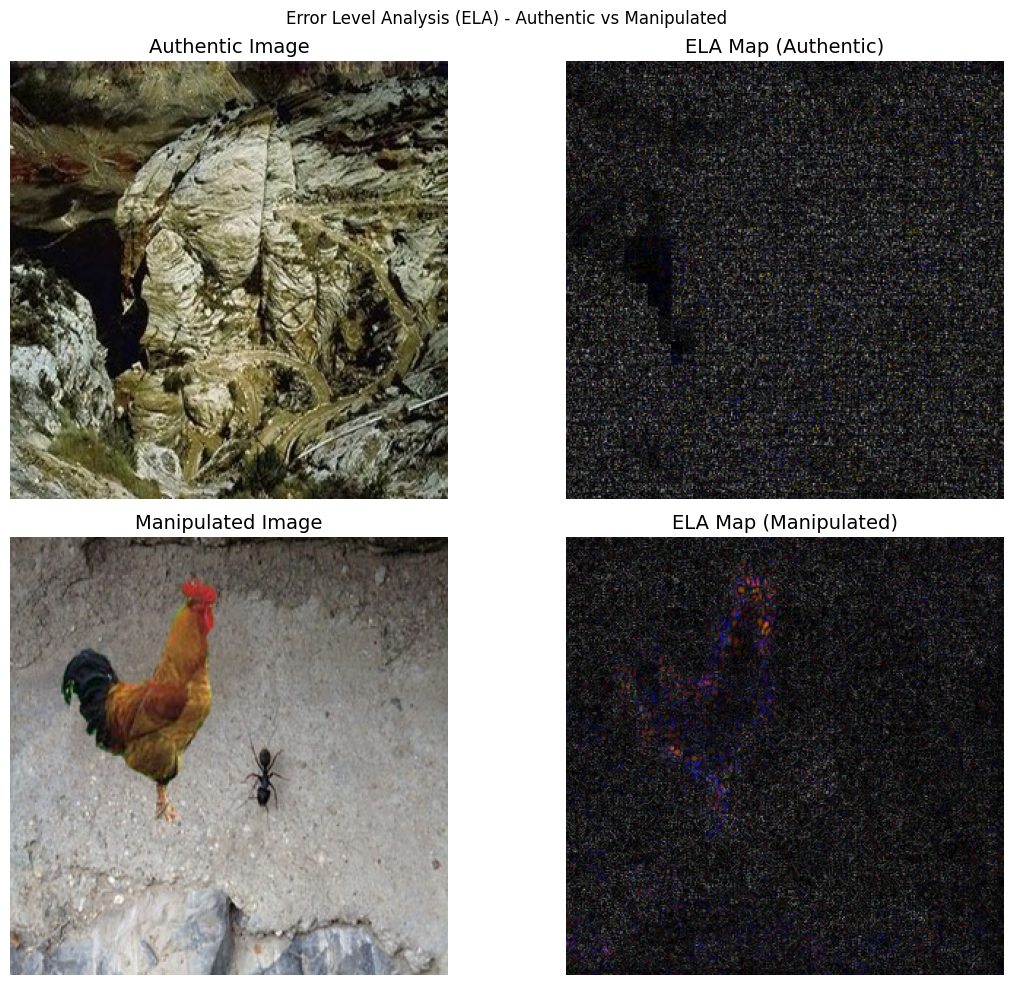

In [3]:
random.seed(42)  # For reproducibility

AU_DIR = Path("../data/processed/Au")
TP_DIR = Path("../data/processed/Tp")

au_sample = random.choice(list(AU_DIR.glob("*.jpg")))
tp_sample = random.choice(list(TP_DIR.glob("*.jpg")))

fig, axes = plt.subplots(2,2, figsize=(12, 10))
fig.suptitle("Error Level Analysis (ELA) - Authentic vs Manipulated")

for row, (path, label) in enumerate([(au_sample, "Authentic"), (tp_sample, "Manipulated")]):
    original, ela_img = ela(path)

    axes[row, 0].imshow(original)
    axes[row, 0].set_title(f"{label} Image", fontsize=14)
    axes[row, 0].axis("off")

    axes[row, 1].imshow(ela_img)
    axes[row, 1].set_title(f"ELA Map ({label})", fontsize=14)
    axes[row, 1].axis("off")

plt.tight_layout()
plt.show() 

As we expected we can observe that the ELA image highlights the areas that have been altered, making it easier to identify potential manipulations. We will use this ELA feature as a channel for our model to learn to distinguish between real and fake images.

## Why can't we just use the ELA image?
While the ELA image provides valuable information about potential manipulations, it is not sufficient on its own to determine whether an image is real or fake. The ELA image highlights areas of potential alteration, but it does not provide context about the content of the image or the nature of the manipulation. By combining the original image with the ELA image, we can leverage both the visual content and the forensic information to train a more robust model that can better distinguish between real and fake images.

We will display the original image, the ELA image and the ground truth label side by side to visually inspect the differences and limitations of ELA visually. 

>**NOTE:** Ground truth masks (They represent the actual manipulated regions in fake images) are not used for training the model but are included here for exploratory purposes to understand the relationship between the ELA image and the actual label of the image (real or fake).



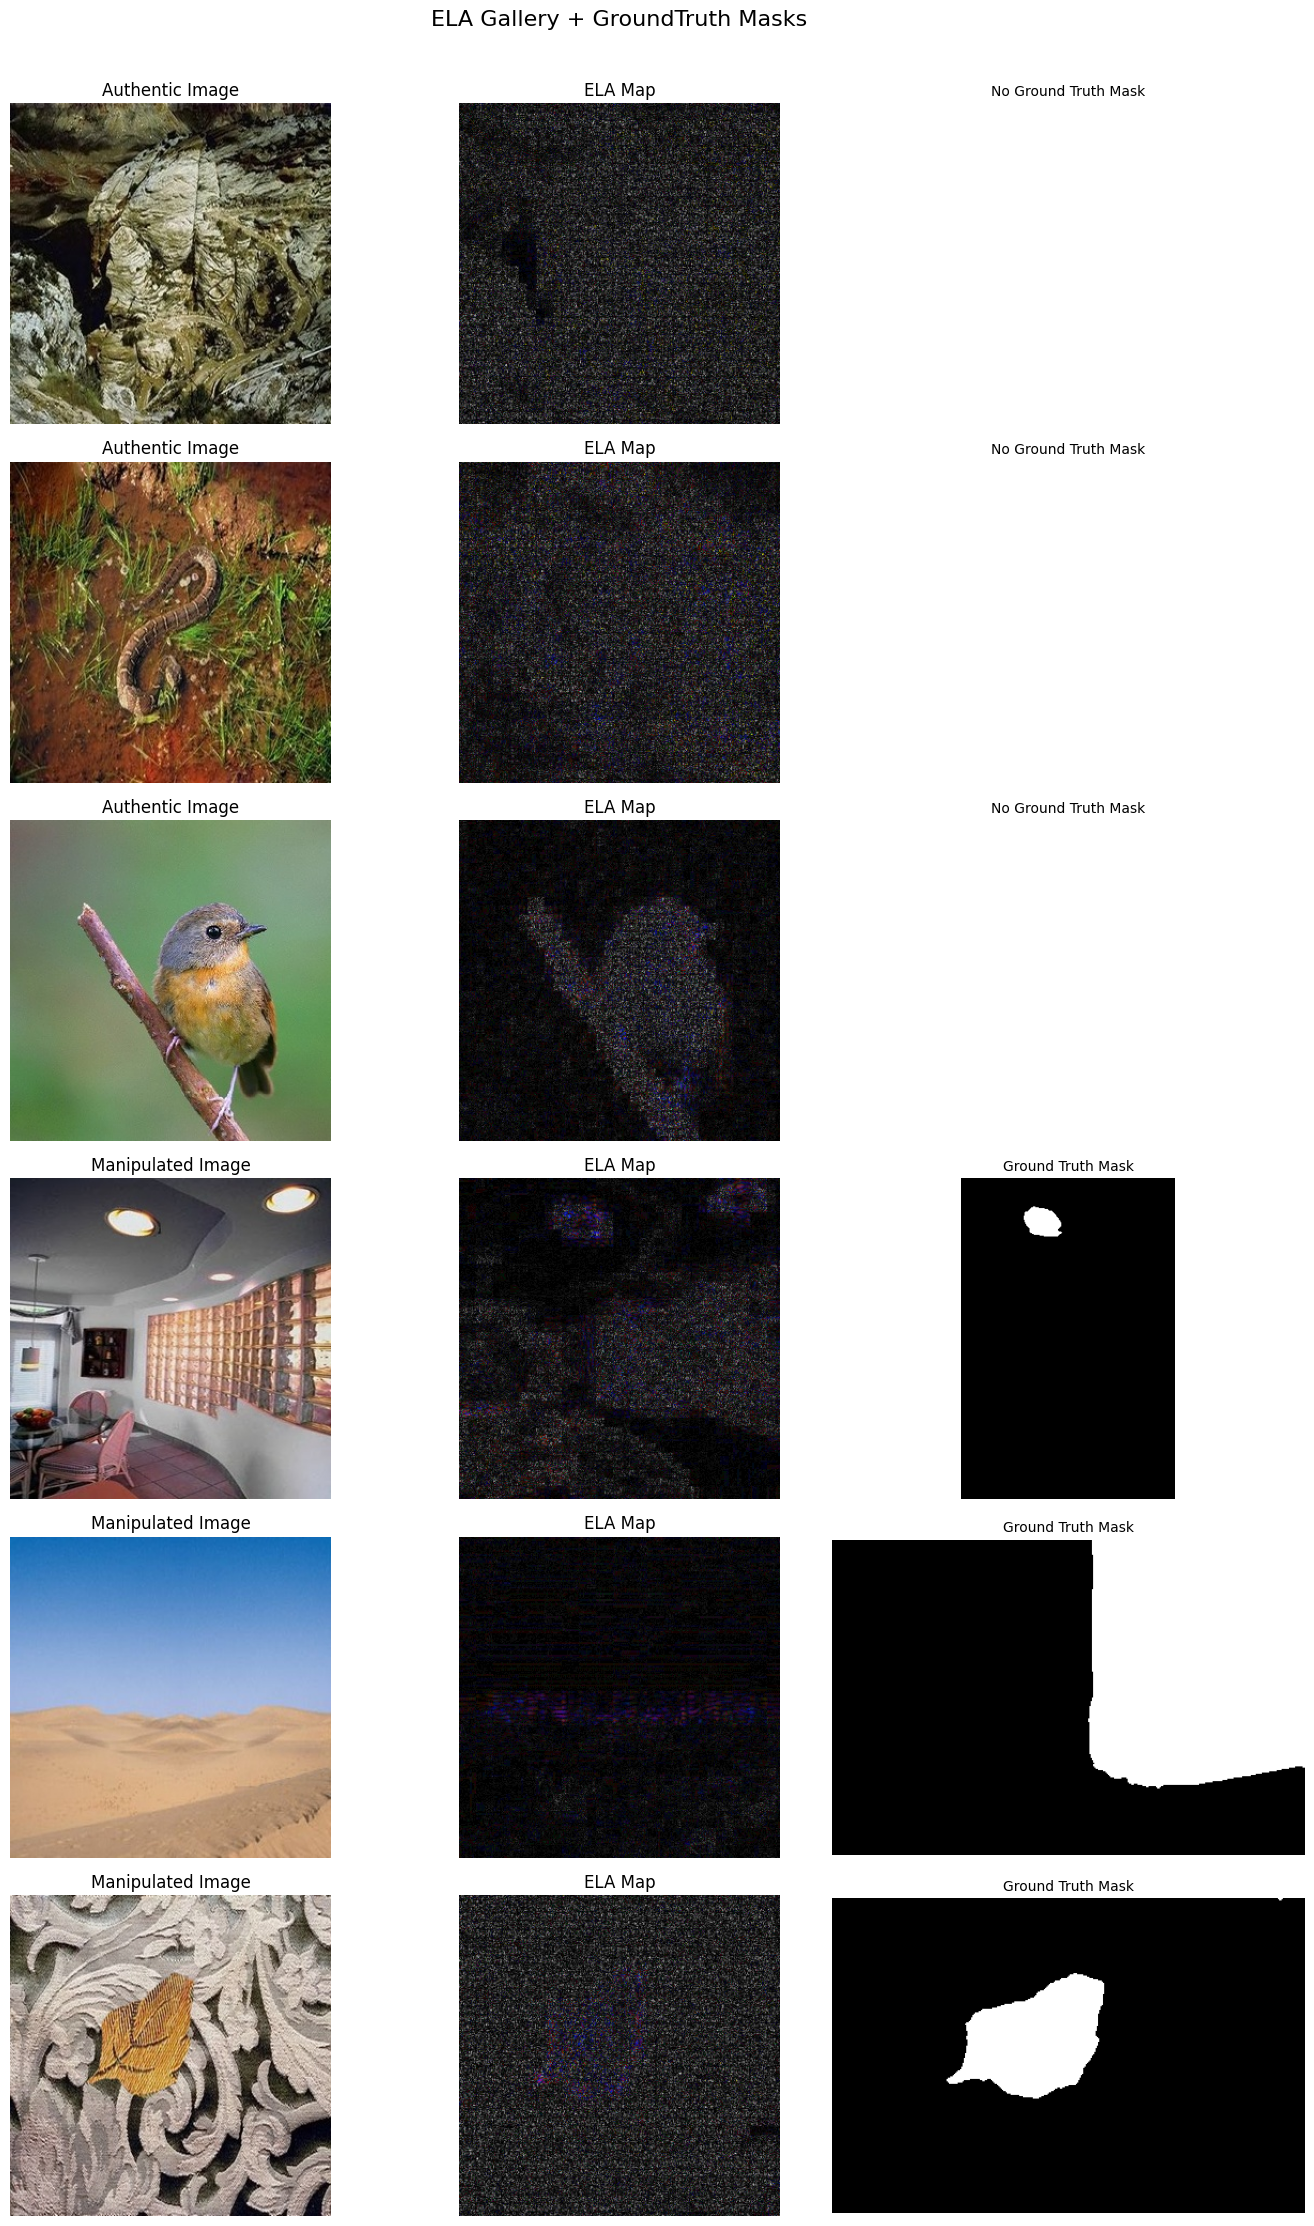

In [4]:
random.seed(42)  # For reproducibility
fig, axes =plt.subplots(6,3, figsize=(14, 22)) 
fig.suptitle("ELA Gallery + GroundTruth Masks", fontsize=16, y=1.01)

GT_DIR = Path("../data/raw/CASIA2/CASIA 2 Groundtruth")

# 3 Authentic and 3 Manipulated samples
au_samples = random.sample(list(AU_DIR.glob("*.jpg")), 3)
tp_samples = random.sample(list(TP_DIR.glob("*.jpg")), 3)

samples = [(p, "Authentic", False) for p in au_samples] + [(p, "Manipulated", True) for p in tp_samples]

for row, (path, label, has_mask) in enumerate(samples):
    original, ela_img = ela(path)

    axes[row, 0].imshow(original)
    axes[row, 0].set_title(f"{label} Image", fontsize=12)
    axes[row, 0].axis("off")

    axes[row, 1].imshow(ela_img)
    axes[row, 1].set_title(f"ELA Map", fontsize=12)
    axes[row, 1].axis("off")

    if has_mask:
        stem=path.stem
        mask_candidates = list(GT_DIR.glob(f"*{stem}*"))
        if mask_candidates:
            mask = Image.open(mask_candidates[0]).convert("L")
            axes[row, 2].imshow(mask, cmap="gray")
            axes[row, 2].set_title("Ground Truth Mask", fontsize=10)
        else:
            axes[row, 2].set_title("Ground Truth Mask - Not Found", fontsize=10)
    
    else:
        axes[row, 2].set_title("No Ground Truth Mask", fontsize=10)
    axes[row, 2].axis("off")

plt.tight_layout()
plt.show()

As we can see, the ELA image highlights the areas that have been altered, making it easier to identify potential manipulations. Nonetheless in the second manipulated image (Desert) ELA is not enought to highlight the manipulated area. For such reason we cannot raly on ELA alone to determine if an image is real or fake, but it can be a useful feature to combine with the original image for training our model as explained before.

## IoU between ELA and Ground Truth Masks
To quantitatively evaluate the effectiveness of ELA in highlighting manipulated areas, we can calculate the Intersection over Union (IoU) between the ELA image and the ground truth masks. The IoU is a common metric used in image segmentation tasks to measure the overlap between two binary masks. In this case, we will treat the ELA image as a binary mask (after thresholding) and compare it with the ground truth mask to see how well ELA captures the manipulated regions.

**NOTE:** The data we are using is has not being splitted into train and test sets, so we are using the same images for both training and evaluation. This is not ideal for a real-world scenario, but it allows us to explore the relationship between ELA and the ground truth masks in this context. For such reason we won't try to adjust the quality hyperparameter yet and we will just use a fixed value of 90% for all the images.

In [5]:
def ela_mask_overlap(image_path, mask_path, quality=90, amplify=10, threshold=30):
    """
    Measures how much the ELA map overlaps with the ground truth mask.
    Converts both to binary and computes IoU (Intersection over Union).

    IoU = overlapping area / union area
    IoU = 1.0 -> perfect match
    IoU = 0.0 -> no overlap at all
    """

    # ELA
    _ , ela_img = ela(image_path, quality, amplify)
    ela_gray = np.array(ela_img.convert("L"))
    ela_binary = (ela_gray > threshold)

    # Ground Truth Mask
    mask=np.array(Image.open(mask_path).convert("L").resize(ela_img.size))
    mask_bin=mask>128

    # IoU Calculation
    intersection = (ela_binary & mask_bin).sum()
    union = (ela_binary | mask_bin).sum()
    iou = intersection / union if union > 0 else 0

    return iou

In [6]:
random.seed(42)  # For reproducibility

# 50 manipulated images
tp_files = list(TP_DIR.glob("*.jpg"))

ious = []

print("- ELA Mask Overlap (IoU) for a Manipulated Image:")
for tp_path in random.sample(tp_files, min(50, len(tp_files))):
    stem = tp_path.stem
    mask_candidates = list(GT_DIR.glob(f"*{stem}*"))
    if mask_candidates:
        iou = ela_mask_overlap(tp_path,mask_candidates[0])
        ious.append(iou)

print(f"\nResults on {len(ious)} manipulated images:")
print(f"  Mean IoU:   {np.mean(ious):.3f}")
print(f"  Median IoU: {np.median(ious):.3f}")
print(f"  Max IoU:  {np.max(ious):.3f}")
print(f"  Min IoU:  {np.min(ious):.3f}")


- ELA Mask Overlap (IoU) for a Manipulated Image:

Results on 48 manipulated images:
  Mean IoU:   0.051
  Median IoU: 0.027
  Max IoU:  0.234
  Min IoU:  0.001


Our results show that the IoU between the ELA image and the ground truth masks is relatively low, which indicates that while ELA can highlight some of the manipulated areas, it does not perfectly capture all of them. This further reinforces the idea that ELA should be used as a complementary feature rather than a standalone method for detecting manipulated images. As we observed before, ELA usually highlights the contours of the manipulated areas, but it may not capture the entire region, which one of the reasons for the lower IoU values. In addition, our processed images were already compressed to 95% quality, which reduce the differences between the original and recompressed images, making it harder for ELA to detect manipulations effectively.